In [1]:
import pandas as pd

df=pd.read_csv('../data/raw/DuplicateQuestion.csv')

df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [4]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
163944,163944,235163,19553,What do Chinese people think about Indians?,What do Chinese people think of Indians?,1
284315,284315,404540,404541,What is the top 20 percentile of bihar board f...,How many marks in twelfth Bihar Board is requi...,0
262801,262801,379217,379218,How do I start a property management firm?,How can I start a property management company?,1
144318,144318,66066,228435,What is a good inpatient drug and alcohol reha...,Which is a good inpatient drug and alcohol reh...,0
389631,389631,20384,122959,How much time do you need to spend on Quora to...,How might I improve my answers on Quora to bec...,1


In [5]:
df.shape

(404290, 6)

In [6]:
df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [7]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [8]:
df=df.sample(50000,random_state=42)

In [9]:
df.shape

(50000, 6)

In [10]:
df.isnull().sum()


id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [12]:
df.to_csv(
    '../data/processed/sample_50k.csv'
)

In [13]:
df['is_duplicate'].value_counts()

is_duplicate
0    31547
1    18453
Name: count, dtype: int64

<Axes: xlabel='is_duplicate'>

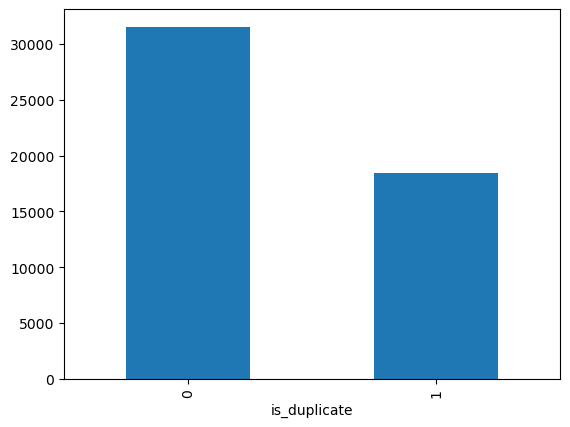

In [15]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(kind='bar')

In [16]:
#observing some duplicate examples

duplicates=df[df['is_duplicate']==1]

duplicates[['question1','question2']].head(10)

,question1,question2
226567,How do I improve logical programming skills?,How can I improve my logical skills for progra...
73186,How close we are to see 3rd world war?,How close is a World War III?
215105,What do Chinese people think about Donald Trump?,What do Chinese people think of Donald Trump?
104478,Why are cats so overprotective?,How do you know if your cat is overprotective?
163628,How do I improve logical programming skills?,What is the best way to improve logical skills...
224862,Is China trying to divert river Brahmaputra? I...,"Will India suffer, if China blocks Brahmaputra..."
213029,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem..."
174208,How much does an architect earn in India?,How much architects earn in India?
44558,Where can I download tv series?,Which is the best website to download TV shows?
192038,Does reading more improve memory?,How does reading improve memory?


In [18]:
non_duplicates=df[df['is_duplicate']==0]

non_duplicates[['question1','question2']].head(10)

,question1,question2
8067,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?
368101,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...
70497,Which is more advisable and better material fo...,What is the best server setup for buddypress?
253209,How many hours a week do Google employees work?,How many hours a day do Google employees work ...
354651,How can we follow a Quora question privately w...,How can we view private Instagram pictures wit...
258826,How do I access reddit in Indonesia since the ...,How is Reddit governed?
121370,What are the travel API's in India?,What is travel API?
384975,"How do I tell my parents I'm not ""grumpy"", I'm...",Why do meat eaters get grumpy?
245470,Moto g4 screen is all black lights light up bu...,What would you do if you owned a dog with a hu...
30812,"My face skin is so dry, which cream or facewas...",What is the best face cream available in India...


Question length analysis

In [20]:
df['q1_len']=df['question1'].str.len()

print(df['q1_len'])

8067       34
368101     53
70497      96
226567     44
73186      38
         ... 
16314     159
258955     38
174632     71
337708     44
57909      85
Name: q1_len, Length: 50000, dtype: int64


<Axes: >

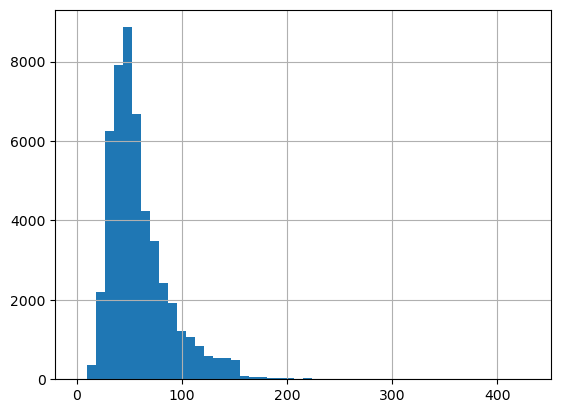

In [21]:
df['q1_len'].hist(bins=50)

generally question 1 length is avg 50

In [22]:
df['q2_len'] = df['question2'].str.len()

In [23]:
df[['q1_len','q2_len']].describe()

,q1_len,q2_len
count,50000.000000,50000.000000
mean,59.688700,59.999540
std,30.306019,33.286004
min,1.000000,1.000000
25%,39.000000,39.000000
50%,52.000000,51.000000
75%,72.000000,71.000000
max,430.000000,1169.000000


# word count analysis


In [25]:
df['q1_words']=df['question1'].apply(
    lambda x: len(str(x).split())
)

df['q2_words']=df['question2'].apply(
    lambda x: len(str(x).split())
)

df.head()

In [27]:
df[['q1_words','q2_words']].describe()

,q1_words,q2_words
count,50000.000000,50000.000000
mean,10.963580,11.162520
std,5.486304,6.186747
min,1.000000,1.000000
25%,7.000000,7.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,80.000000,228.000000


# Most Common words

In [28]:
from collections import Counter

all_text=" ".join(df['question1'].astype(str))

words=all_text.split()

Counter(words).most_common(20)

[('the', 22988),
 ('What', 18119),
 ('is', 13192),
 ('I', 12581),
 ('a', 12537),
 ('How', 12393),
 ('to', 12036),
 ('in', 11617),
 ('of', 9812),
 ('do', 8466),
 ('are', 8395),
 ('and', 8116),
 ('for', 6150),
 ('can', 5428),
 ('you', 5155),
 ('Why', 4381),
 ('best', 4088),
 ('my', 3879),
 ('on', 3653),
 ('it', 3497)]

In [29]:
def common_words(q1,q2):
    w1=set(str(q1).lower().split())
    w2=set(str(q2).lower().split())

    return len(w1.intersection(w2))

In [30]:
df['common_words']=df.apply(
    lambda row:
    common_words(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [31]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,7
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9,6
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8,2
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9,4
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7,3


In [32]:
df['common_words'].describe()

count    50000.000000
mean         4.512700
std          3.102636
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         35.000000
Name: common_words, dtype: float64

In [34]:
df = df.dropna()

df.to_csv(
    "../data/processed/sample_50k.csv",
    index=False
)

# Observations

- 4 lakh row but choose random 50k rows
- no null values
- class distribution is 63% and 37 %
- most questions have 50 to 70 words